# Phase 2 - Logistic Regression

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 2. Import Preprocessed Data

In [2]:
X_train = pd.read_csv('preprocessed/X_train_scaled.csv')
X_test = pd.read_csv('preprocessed/X_test_scaled.csv')
y_train = pd.read_csv('preprocessed/y_train.csv').iloc[:, 0]
y_test = pd.read_csv('preprocessed/y_test.csv').iloc[:, 0]

print("Training", X_train.shape, y_train.shape)
print("Testing", X_test.shape, y_test.shape)

Training (1322089, 127) (1322089,)
Testing (566610, 127) (566610,)


## 3. Logistic Regression Training

### 3.1 Separating Validation Data for Hyperparameter Tuning

In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

### 3.2 Hyperparameter Tuning

This section uses a manual grid search with stratified holdout validation. The most important hyperparameter is `C`, which controls regularization strength. Smaller `C` values apply stronger regularization and can reduce overfitting, while larger `C` values allow the model to fit the training data more closely. The solver controls the optimization method used to estimate the model coefficients. Validation AUC is used to select the best configuration because the dataset is imbalanced and AUC measures ranking quality across thresholds.

In [4]:
param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "solver": ["newton-cg", "lbfgs"],
    "class_weight": ["balanced", None]
}

configs = list(product(
    param_grid["C"],
    param_grid["solver"],
    param_grid["class_weight"]
))

tuning_rows = []

for C, solver, class_weight in configs:
    print(f"Testing C={C}, solver={solver}, class_weight={class_weight}")

    model = LogisticRegression(
        C=C,
        solver=solver,
        class_weight=class_weight,
        max_iter=300
    )

    model.fit(X_tr, y_tr)

    y_val_prob = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_prob >= 0.5).astype(int)

    tuning_rows.append({
        "C": C,
        "solver": solver,
        "class_weight": class_weight,
        "val_auc": roc_auc_score(y_val, y_val_prob),
        "val_avg_precision": average_precision_score(y_val, y_val_prob),
        "val_f1": f1_score(y_val, y_val_pred)
    })

Testing C=0.01, solver=newton-cg, class_weight=balanced
Testing C=0.01, solver=newton-cg, class_weight=None
Testing C=0.01, solver=lbfgs, class_weight=balanced
Testing C=0.01, solver=lbfgs, class_weight=None
Testing C=0.1, solver=newton-cg, class_weight=balanced
Testing C=0.1, solver=newton-cg, class_weight=None
Testing C=0.1, solver=lbfgs, class_weight=balanced
Testing C=0.1, solver=lbfgs, class_weight=None
Testing C=1.0, solver=newton-cg, class_weight=balanced
Testing C=1.0, solver=newton-cg, class_weight=None
Testing C=1.0, solver=lbfgs, class_weight=balanced
Testing C=1.0, solver=lbfgs, class_weight=None
Testing C=10.0, solver=newton-cg, class_weight=balanced
Testing C=10.0, solver=newton-cg, class_weight=None
Testing C=10.0, solver=lbfgs, class_weight=balanced


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Testing C=10.0, solver=lbfgs, class_weight=None


### 3.3 Selecting the Best Configuration and Training the Final Model

In [5]:
tuning_results = pd.DataFrame(tuning_rows).sort_values("val_auc", ascending=False)
best_params = tuning_results.iloc[0]
tuning_results

,C,solver,class_weight,val_auc,val_avg_precision,val_f1
12,10.00,newton-cg,balanced,0.738598,0.946939,0.770950
8,1.00,newton-cg,balanced,0.738474,0.946922,0.770933
14,10.00,lbfgs,balanced,0.737979,0.946780,0.771090
10,1.00,lbfgs,balanced,0.737952,0.946772,0.770937
4,0.10,newton-cg,balanced,0.737756,0.946798,0.770329
6,0.10,lbfgs,balanced,0.737429,0.946703,0.770244
13,10.00,newton-cg,NaN,0.737231,0.946398,0.930315
9,1.00,newton-cg,NaN,0.737161,0.946388,0.930316
15,10.00,lbfgs,NaN,0.736714,0.946209,0.930307
11,1.00,lbfgs,NaN,0.736552,0.946175,0.930301


### Why This Configuration Was Selected

The best logistic regression configuration was selected using the highest validation AUC. This choice is appropriate because the Lending Club dataset is imbalanced, and AUC evaluates how well the model ranks positive and negative outcomes across different thresholds instead of depending only on the default 0.5 cutoff.

The selected configuration represents the best tradeoff among the tested regularization strengths, solvers, and class weighting options. After selecting the best hyperparameters, the final logistic regression model is retrained on the full training set and then evaluated using the existing test-set analysis below.

In [6]:
# Train the final model using the best hyperparameters from validation tuning.
lr_model = LogisticRegression(
    C=float(best_params["C"]),
    solver=best_params["solver"],
    class_weight=best_params["class_weight"],
    max_iter=300
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :te

## 4. Model Evaluation

To evaluate the logistic regression model, we used a diverse set of metrics rather than relying solely on accuracy. This is important because the Lending Club dataset is highly imbalanced: there are a lot more non-default loans than default loans. In such settings, a model can achieve deceptively high accuracy simply by predicting the majority class.

For this reason, we measured performance using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- AUC-ROC  
- Precision-Recall behavior

Together, these metrics offer a more complete understanding of how well the model predicts low-risk and high-risk loans.

---

### Why Accuracy Alone Is Not Enough

In imbalanced classification problems, accuracy can hide important behavior. A model may have high accuracy while performing badly on the minority class or lower accuracy while doing a better job detecting rare but important outcomes.

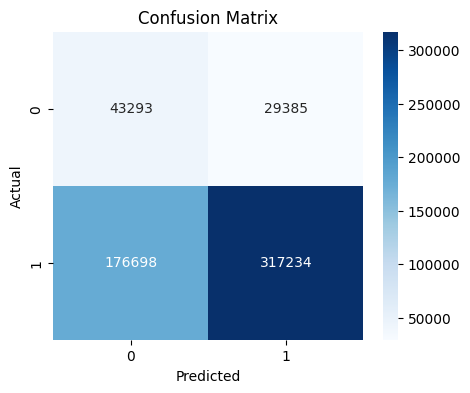


Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.60      0.30     72678
           1       0.92      0.64      0.75    493932

    accuracy                           0.64    566610
   macro avg       0.56      0.62      0.53    566610
weighted avg       0.82      0.64      0.70    566610



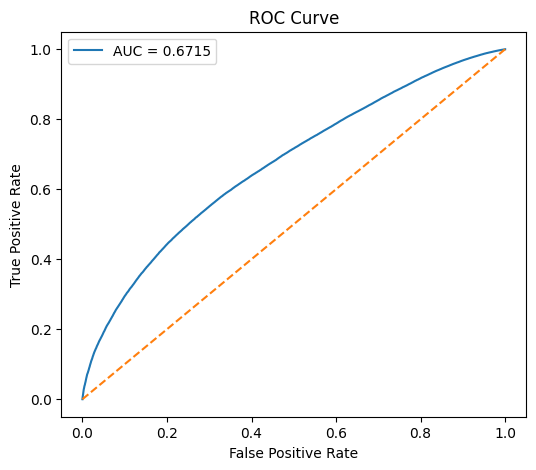

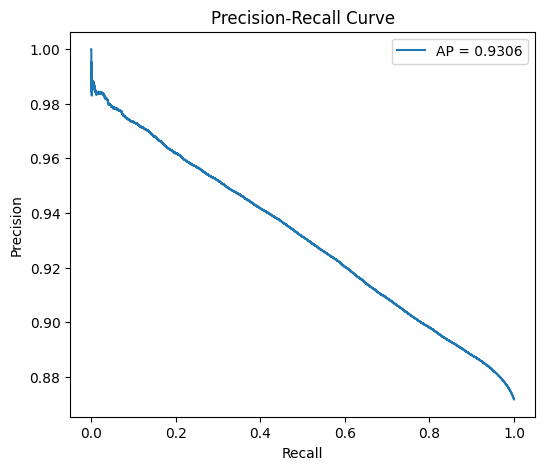

In [7]:
# Probability scores for the test set
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Starting with the standard 0.5 cutoff.
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
auc_roc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
avg_precision = average_precision_score(y_test, y_prob)
plt.plot(recalls, precisions, label=f"AP = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


### Training Outcome

Given the results above, the logistic regression model shows evidence of learning meaningful predictive patterns from the preprocessed loan data produced in Phase 1. The model converged successfully and performs much better than random guessing, making it a useful baseline for Phase 2.

Its overall ranking performance is moderate, with a test AUC-ROC of about **0.67**. This means logistic regression is able to separate lower-risk and higher-risk borrowers to a reasonable extent.

---

### Confusion Matrix Interpretation

At the default threshold of 0.5, the confusion matrix shows:

- The model correctly identifies a large number of non-default loans  
- It also captures a meaningful portion of default cases because of the balanced training setup  
- Some errors remain, especially false approvals and rejected good loans

Note: False positives and false negatives do not carry the same cost, so threshold selection remains a key part of the model strategy. The next section analyzes how different thresholds affect lending decisions.

---

### Classification Report

The classification report shows that the model has strong precision on the non-default class but weaker precision on the default class. At the 0.5 threshold, it achieves about **0.92 precision** and **0.64 recall** for non-default loans, while the default class has much lower precision but still meaningful recall. This suggests the model is usable, but its raw threshold decisions need to be tuned for the business objective.

---

### AUC-ROC and Ranking Performance

The model achieved a test AUC-ROC of about **0.67**, indicating moderate separability. This confirms that logistic regression is learning useful signal from the engineered features, while also showing why threshold tuning is important for improving practical lending decisions.

## 5. Banking Strategies

### Threshold Analysis

To better understand tradeoffs between precision and recall, the model was evaluated using several thresholds: 0.3, 0.4, 0.5, 0.6, 0.7, 0.8

These results show a clear tradeoff:

- Lower thresholds approve more loans and give higher recall, but they also allow more bad approvals  
- Higher thresholds increase precision and reduce bad approvals, but they sharply reduce recall and total approvals  
- The default threshold of 0.5 provides a reasonable middle ground, while 0.6 and above represent a more conservative lending strategy

For example, moving from 0.5 to 0.6 raises precision from about **0.9152** to **0.9331** and cuts bad approvals from **29,385** to **17,093**, but recall drops from **0.6423** to **0.4830**. This shows how quickly the model becomes stricter as the threshold increases.

These tradeoffs confirm that threshold tuning is necessary. The best threshold depends on the business goal:

- If the goal is to identify as many risky loans as possible, choose a lower threshold  
- If the goal is to reduce false approvals and stay conservative, choose a higher threshold  

For banking purposes, a threshold slightly above 0.5 may be the better choice for logistic regression because it reduces risky approvals while still keeping a meaningful number of approvals.

In [8]:
# Comparing several cutoffs to see how different strategies change our outcome.
# Note: We are trading recall for precision as we increase the threshold, which means we will approve fewer loans but with higher confidence.
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Approved (TP+FP): {tp+fp}")
    print(f"Bad approvals (FP): {fp}")
    print("---")

Threshold: 0.3
Precision: 0.8909
Recall:    0.8702
F1 Score:  0.8804
Approved (TP+FP): 482452
Bad approvals (FP): 52625
---
Threshold: 0.4
Precision: 0.9010
Recall:    0.7697
F1 Score:  0.8302
Approved (TP+FP): 421988
Bad approvals (FP): 41786
---
Threshold: 0.5
Precision: 0.9152
Recall:    0.6423
F1 Score:  0.7548
Approved (TP+FP): 346619
Bad approvals (FP): 29385
---
Threshold: 0.6
Precision: 0.9331
Recall:    0.4830
F1 Score:  0.6366
Approved (TP+FP): 255679
Bad approvals (FP): 17093
---
Threshold: 0.7
Precision: 0.9513
Recall:    0.3052
F1 Score:  0.4622
Approved (TP+FP): 158477
Bad approvals (FP): 7718
---
Threshold: 0.8
Precision: 0.9691
Recall:    0.1409
F1 Score:  0.2461
Approved (TP+FP): 71825
Bad approvals (FP): 2218
---


## 6. Saving Results (Phase 3)

In [9]:
# Default-threshold predictions
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Main evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

summary_rows = [
    {"metric": "date", "value": datetime.now().strftime("%Y-%m-%d")},
    {"metric": "threshold", "value": threshold},
    {"metric": "accuracy", "value": accuracy_score(y_test, y_pred)},
    {"metric": "precision", "value": precision_score(y_test, y_pred)},
    {"metric": "recall", "value": recall_score(y_test, y_pred)},
    {"metric": "f1_score", "value": f1_score(y_test, y_pred)},
    {"metric": "roc_auc", "value": roc_auc_score(y_test, y_prob)},
    {"metric": "avg_precision", "value": average_precision_score(y_test, y_prob)},
    {"metric": "tn", "value": tn},
    {"metric": "fp", "value": fp},
    {"metric": "fn", "value": fn},
    {"metric": "tp", "value": tp},
]

summary_df = pd.DataFrame(summary_rows)

# Threshold sweep results
threshold_rows = []
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1_score": f1_score(y_test, y_pred_t),
        "approved_tp_fp": tp + fp,
        "bad_approvals_fp": fp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

threshold_df = pd.DataFrame(threshold_rows)

# File names
date_str = datetime.now().strftime("%Y-%m-%d")
summary_file = f"results/logistic_regression_{date_str}_summary.csv"
threshold_file = f"results/logistic_regression_{date_str}_thresholds.csv"

# Save
summary_df.to_csv(summary_file, index=False)
threshold_df.to_csv(threshold_file, index=False)

print(f"Saved summary to: {summary_file}")
print(f"Saved threshold results to: {threshold_file}")


Saved summary to: results/logistic_regression_2026-04-22_summary.csv
Saved threshold results to: results/logistic_regression_2026-04-22_thresholds.csv
